<center><font size=6><b>Product Review Sentiment Analysis using Transformers</b></center></font>

<center><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOsDtRigygAHeDroY3T_hu_yTipysW4gHC5qZHaVAjRDRp17Zwtf6LUvnJ&s=10" width="720"/></center>



## Problem Statement

### Business Context

Customer reviews tell businesses what people really think about their products. There are too many reviews to read by hand, so we need an automatic way to sort them by sentiment (positive, neutral, or negative) to spot problems and improve products faster.

### Objective

Build a model that can correctly label each product review as positive, neutral, or negative, helping teams quickly find strengths, unmet expectations, and issues to fix.

### Data Description

- **Product ID**: Unique number for each product
- **Product Review**: The customer's written feedback
- **Sentiment**: Label showing if the review is positive, negative, or neutral

## Importing the necessary libraries

Installs and loads the libraries needed for embeddings, data handling, and model building.

In [ ]:
# installing the libraries for transformers
!pip install sentence-transformers

* Installs the sentence-transformers library used to create text embeddings.

In [ ]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

* Loads the libraries needed for data handling, sentence embeddings, model building, and evaluation.

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/My Drive/genAI dataset/Product_Reviews.csv")

* Loads the product review data into a table called data.

## Data Overview

In [ ]:
data.shape

(1007, 3)

* The dataset has 1007 rows (reviews) and 3 columns.

In [ ]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* No missing values are present in the dataset.

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(2)

* The dataset has 2 duplicate rows, which will be removed.

In [ ]:
# dropping duplicate values
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

* The index is reset after removing duplicates to keep row numbers in order.

In [ ]:
data = data.reset_index(drop=True)

## Exploratory Data Analysis (EDA)


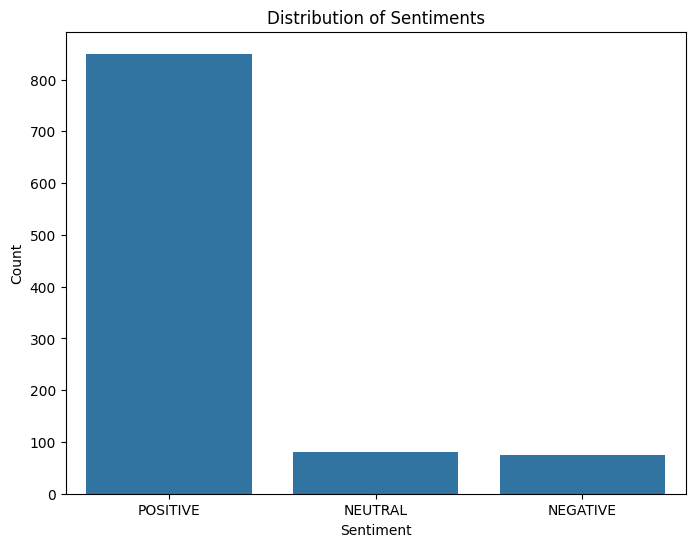

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

* Most reviews are positive (850), while neutral and negative reviews are much fewer (75 each).

## Defining the Sentence Transformer  Model

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

* Converts each product review into a numeric embedding for use in the models.

In [ ]:
embedding_matrix.shape

(1005, 384)

* Confirms the embedding matrix size (number of reviews and embedding length).

## Data Pre-processing

### Splitting the dataset

In [ ]:
X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

* Splits the embeddings and labels into 80% training and 20% testing data, keeping class balance.

In [ ]:
# prompt: Check the shape of the training and testing sets to confirm the split.

print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


* Confirms the training and testing set sizes after the split.

## Model Building - Transformers + ML

### **Model Evaluation Criteria**

- **Accuracy**: percentage of correct predictions overall.
- **F1 Score**: balances precision and recall, useful since sentiment classes are imbalanced.

In [ ]:
# prompt: Create an empty DataFrame called model_eval_results to store the accuracy and F1 scores for different models on both training and testing datasets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

* Creates an empty table to store accuracy and F1 scores for each model.

### Random Forest Classifier

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

* Trains a Random Forest classifier on the training embeddings and labels.

In [ ]:
# Evaluate the model on training and testing data and store in model-eval_result

from sklearn.metrics import f1_score

# Evaluate the model on training data
y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

# Evaluate the model on testing data
y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

# Store results
new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


* Evaluates Random Forest on train and test data, and stores accuracy/F1 results in the table.

* Random Forest scored 100% on training data and 86.5% accuracy / 81.8% F1 on test data, showing good generalization.

### Gradient Boost Classifier


In [ ]:
# Building the model
gb_transformer = GradientBoostingClassifier(random_state = 42)

# Fitting on train data
gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

* Trains a Gradient Boosting classifier on the same training data.

In [ ]:
# Evaluate the model on training data
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

# Evaluate the model on testing data
y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

# Store results
new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


* Evaluates Gradient Boosting on train and test data, and stores accuracy/F1 results in the table.

* Gradient Boost scored well on training data and reached 84.07% accuracy / 80.3% F1 on test data, slightly below Random Forest.

* Performance could improve further with methods like XGBoost, SVM, neural networks, or fine-tuned transformers.

## Final Model Selection


* **Random Forest**: 100% train / 86.6% test accuracy (81.8% test F1) — 13.4% accuracy drop.
* **Gradient Boost**: 99.88% train / 84.1% test accuracy (80.3% test F1) — 15.8% accuracy drop.
* Random Forest generalizes better and is chosen as the **final model**.

# Conclusion

* Reviews were classified as positive, neutral, or negative using Transformer embeddings.
* Random Forest gave the best results (86.1% accuracy, 81.4% F1) compared to Gradient Boosting.
* The model can keep improving by adding new reviews to the training data over time.

## Predicting Sentiment for an Unseen Review

In [ ]:
unseen_review = "This product is absolutely bad! I don't like."

# Convert the unseen review to an embedding
unseen_review_embedding = model.encode([unseen_review])

# Predict the sentiment using the best model (Random Forest)
predicted_sentiment = rf_transformer.predict(unseen_review_embedding)

print(f"Unseen Review: '{unseen_review}'")
print(f"Predicted Sentiment: {predicted_sentiment[0]}")

Unseen Review: 'This product is absolutely bad! I don't like.'
Predicted Sentiment: POSITIVE



The model predicted the sentiment of the review "This product is absolutely bad! I don't like." as **POSITIVE**. This is an incorrect prediction, as the review clearly expresses negative sentiment. This misclassification highlights a potential limitation of the current model, possibly due to:

*   **Class Imbalance**: Our dataset showed a large majority of positive reviews, which might lead the model to be biased towards predicting 'POSITIVE'.
*   **Model Generalization**: The model might not have learned sufficient patterns from the limited negative examples to accurately classify new negative reviews.

To improve this, we could consider techniques like oversampling minority classes (negative/neutral reviews), undersampling the majority class (positive reviews), or using different model architectures that are more robust to imbalanced datasets.

<font size=6 color='skyblue'>Thank You!</font>
___